In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import logging

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] | %(name)s | %(message)s",
    force=True,
)

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from pyintval import Interval

from pwlopt.fitting.fitting import PWLApproximation
from pwlopt.fitting.functions import fun0, ivfun0_gradnorm
from pwlopt.fitting.interval_bb import Box2D, IntervalBB
from pwlopt.fitting.triangulation import Triangulation


In [4]:
ivbb = IntervalBB(ivfun0_gradnorm, Box2D(Interval(0,1), Interval(0,1)))

In [5]:
_, L = ivbb.maximize(ftol = 0.01, dtol=0.001)

New max inf: [0.0, -inf]
New max inf: [0.0031220426161883024, 0.008388974916496511]
New max inf: [0.0038962028207000475, 0.011013678849736142]
New max inf: [0.005698438311898322, 0.012750770108056662]
New max inf: [0.007626418247295778, 0.013521016654947484]
New max inf: [0.01075506844646501, 0.013521016654947484]
New max inf: [0.012268277077593441, 0.017782463635387956]
New max inf: [0.01613930150699091, 0.017782463635387956]
New max inf: [0.0188547163068415, 0.017782463635387956]
New max inf: [0.02135849761583374, 0.017782463635387956]
New max inf: [0.021829024204910466, 0.03106681911186045]
New max inf: [0.023182463611663384, 0.03106681911186045]
New max inf: [0.023789397143779017, 0.03212510880097322]
New max inf: [0.023862247744387506, 0.032126896271326914]
New max inf: [0.024866945208623488, 0.03233628971148889]
New max inf: [0.029348673097796332, 0.03233628971148889]
New max inf: [0.034205322814061793, 0.03233628971148889]
New max inf: [0.04135941297193686, 0.043439604523210315]

In [13]:
pts = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])

init_trg = Triangulation.from_points(pts)

In [14]:
apx = PWLApproximation(init_trg, fun=fun0, Lip=L, alpha_min_deg=10)

2026-09-07 12:11:14,358 [INFO] | pwlopt.fitting.fitting.PWLApproximation | Initialize PWL approximator for function with Lipschitz const. 50.000, minimal angle 10.000


In [15]:
apx.approximate(.1)

2026-09-07 12:11:15,451 [INFO] | pwlopt.fitting.fitting.PWLApproximation | Run PWL approximation alg. with required error eps = 0.10000, theta = 0.50000
2026-09-07 12:11:15,453 [INFO] | pwlopt.fitting.fitting.PWLApproximation | Perform Lipschitz-correction step
2026-09-07 12:11:15,453 [INFO] | pwlopt.fitting.fitting.PWLApproximation | Upper bound for Lipschitz const. of approximator: 70.71068
2026-09-07 12:11:15,453 [INFO] | pwlopt.fitting.triangle.Triangle | Triangle is not sampled yet, Maximal Poisson Disk Sampling with radius 0.00100
2026-09-07 12:11:21,795 [INFO] | pwlopt.fitting.fitting.PWLApproximation | Iteration #0: new max error found: 0.00000
2026-09-07 12:11:21,795 [INFO] | pwlopt.fitting.triangle.Triangle | Triangle edges not sampled yet, Maximal Poisson Disk Sampling with radius 0.00100
2026-09-07 12:11:21,798 [INFO] | pwlopt.fitting.triangle.Triangle | Triangle is not sampled yet, Maximal Poisson Disk Sampling with radius 0.00100
2026-09-07 12:11:27,877 [INFO] | pwlopt.fi

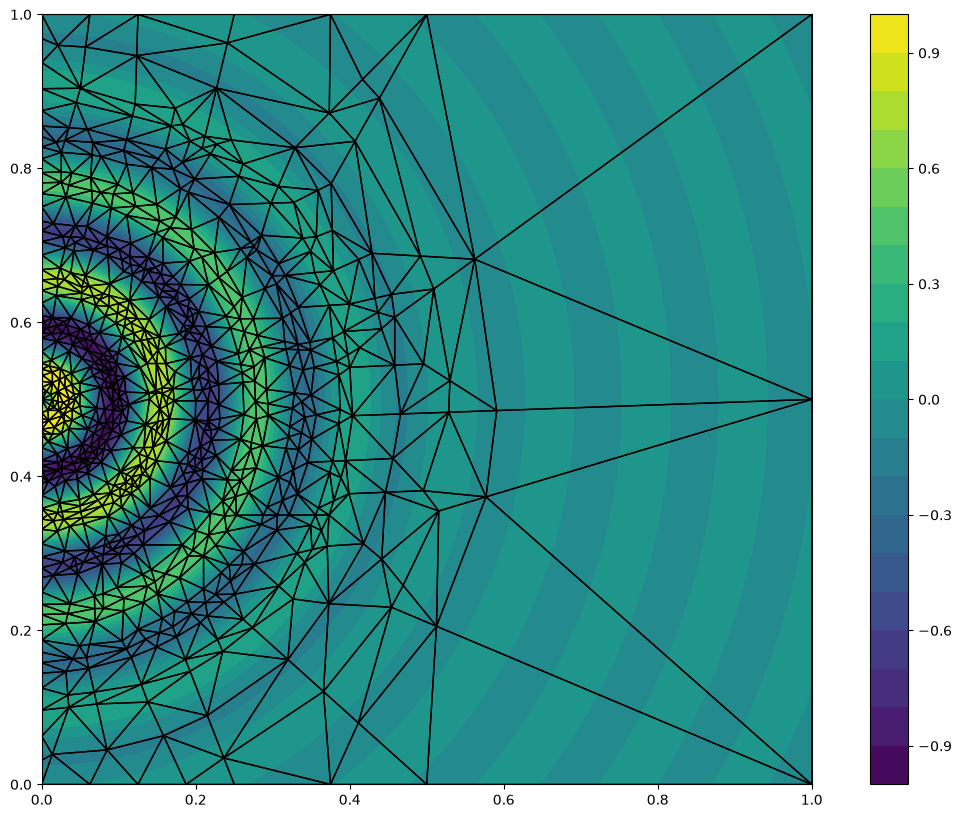

In [16]:
fig, ax = apx.triangulation.plot_triangulation()

X, Y = np.meshgrid(
    np.linspace(0, 1, 200),
    np.linspace(0, 1, 200),
)

p = np.stack((X, Y), axis=-1)

Z = fun0(p)

plt.contourf(X, Y, Z, levels=20)
plt.colorbar()
plt.show()

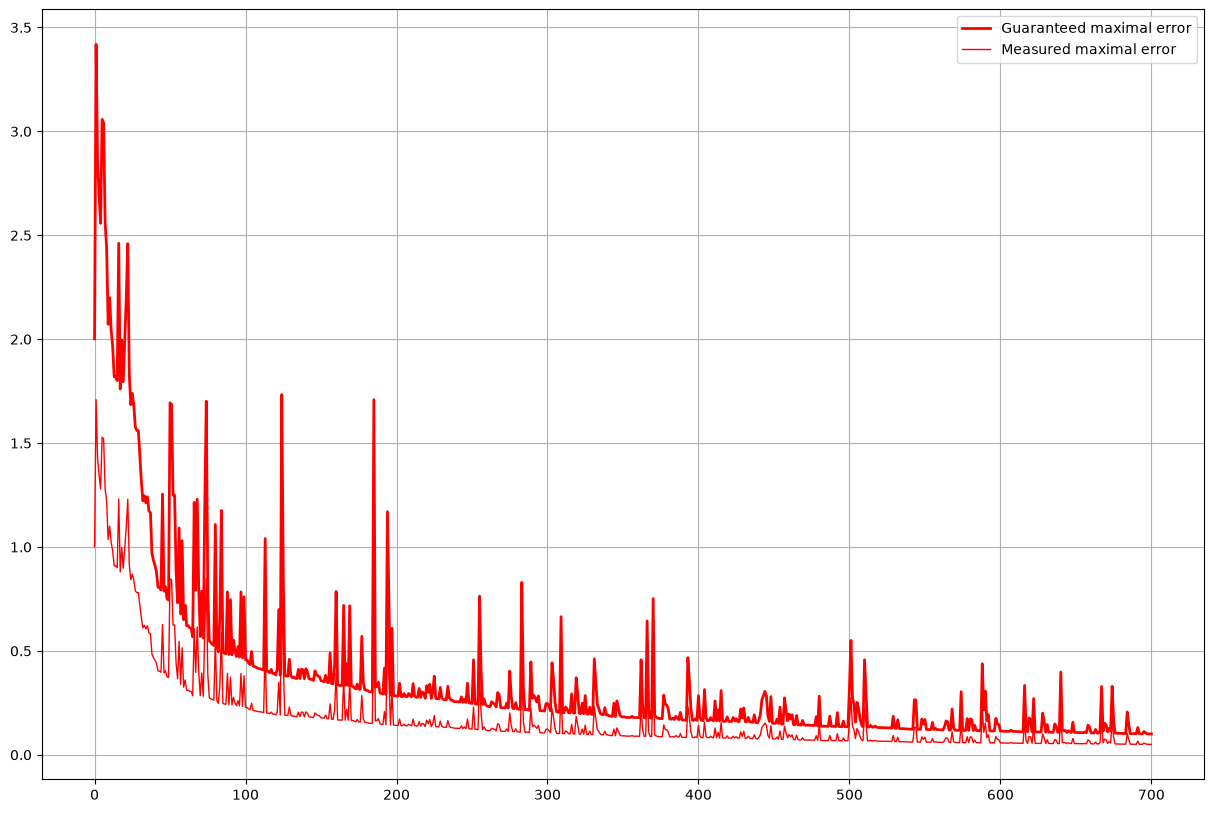

In [31]:
fig, ax = plt.subplots(figsize=(15, 10))
ax.plot([2*err for err in apx.err_hist], color="red", linewidth=2, label="Guaranteed maximal error")
ax.plot([1*err for err in apx.err_hist], color="red", linewidth=1, label="Measured maximal error")
ax.grid()
ax.legend()
plt.show()